# Shapley Values — Explained from Scratch

**Who this is for**: A full-stack engineer who understands code and logic, is learning ML, and wants to understand *why* a model made a specific prediction.

**Author:** Farty Bobo

---

## The problem we're solving

You've trained a model. It predicts that a loan applicant should be **rejected**.

You have four features: age, income, debt, and credit score.

The model says: rejected. But *why*? Was it mainly the debt? The age? Some combination?

This is the **model interpretability** problem. Shapley values are one answer to it.

---

## The core idea in plain English

A Shapley value answers this question:

> **"How much did this one feature contribute to pushing this prediction above (or below) the average prediction?"**

Not globally across all data. Not for the model in general. For **this specific prediction**, for **this specific person**.

Each feature gets a number — its Shapley value. Positive means it pushed the prediction up. Negative means it pushed it down. And they all add up to the total difference between this prediction and the average prediction.

---

## A concrete analogy before any code

Imagine your team ships a feature. Revenue goes up by $10,000. Four engineers worked on it: Alice, Bob, Carol, Dave.

**Question**: How do you fairly credit each engineer?

You can't just say "it's equal" — Alice did the backend, Bob wrote one CSS line. You can't just look at who worked *last*, because order shouldn't matter.

The Shapley approach: **try every possible order in which the team could have assembled, and for each order, measure how much revenue appeared when each person joined.**

- Order: Alice → Bob → Carol → Dave. When Alice joined alone: +$6k. When Bob joined: +$1k. When Carol joined: +$2k. When Dave joined: +$1k.
- Order: Dave → Alice → Carol → Bob. When Dave joined alone: +$1k. When Alice joined: +$7k. Etc.

Average each person's contribution across **all possible orderings**. That average is their Shapley value. It's the fairest possible attribution.

**In ML**: replace "engineers" with "features" and "revenue" with "model prediction."

---

## Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

shap.initjs()

---

## Step 1 — Train a simple model

We'll use the Iris dataset. It's a classic: 150 flowers, 4 measurements each, classified into 3 species.

The 4 features are:
- sepal length
- sepal width
- petal length
- petal width

Think of features as the "inputs" to your model — like columns in a database row.

In [6]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # random_state ensures the same split every run

clf = RandomForestClassifier(n_estimators=100, random_state=42)  # independent from the split above — just sets model reproducibility
clf.fit(X_train, y_train)

print(f'Model accuracy: {clf.score(X_test, y_test):.1%}')
print()
print('A sample flower we will explain:')
sample = X_test.iloc[[0]]
display(sample)
proba = clf.predict_proba(sample)[0]
print(f'Model predicts: {iris.target_names[proba.argmax()]} ({proba.max():.1%} confident)')

Model accuracy: 100.0%

A sample flower we will explain:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
73,6.1,2.8,4.7,1.2


Model predicts: versicolor (99.0% confident)


---

## Step 2 — What's the "average prediction"?

Before we can say a feature pushed the prediction *up* or *down*, we need a reference point: **what would the model predict if it knew nothing about this specific flower?**

The answer: the average prediction across all training flowers.

This is sometimes called the **baseline** or **expected value**. It's the model's "default" before it sees any of your features.

In [7]:
# Average probability the model assigns to each class across all training data
avg_proba = clf.predict_proba(X_train).mean(axis=0)

print('Average (baseline) prediction probabilities across training set:')
for species, p in zip(iris.target_names, avg_proba):
    print(f'  {species}: {p:.3f}')

print()
print('Our sample flower prediction probabilities:')
for species, p in zip(iris.target_names, proba):
    print(f'  {species}: {p:.3f}')

print()
print('Difference (what the Shapley values need to explain):')
for species, diff in zip(iris.target_names, proba - avg_proba):
    print(f'  {species}: {diff:+.3f}')

Average (baseline) prediction probabilities across training set:
  setosa: 0.334
  versicolor: 0.345
  virginica: 0.321

Our sample flower prediction probabilities:
  setosa: 0.000
  versicolor: 0.990
  virginica: 0.010

Difference (what the Shapley values need to explain):
  setosa: -0.334
  versicolor: +0.645
  virginica: -0.311


---

## Step 3 — Computing Shapley values

To compute Shapley values exactly, you'd need to try every possible subset of features and measure how the prediction changes when you add each feature to that subset.

With 4 features there are 2⁴ = 16 subsets — manageable. With 20 features it's over a million. With 50 it's impossible.

For **tree-based models** (like our Random Forest), there's a smarter algorithm — `TreeExplainer` — that computes exact Shapley values by walking the trees directly, without trying every subset. It's fast and exact.

In [8]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test)

# NOTE: this 3D shape (n_samples, n_features, n_classes) is specific to multiclass classifiers.
# For a binary classifier you may get (n_samples, n_features) or (n_samples, n_features, 2).
# For a regressor there is no class dimension: (n_samples, n_features).
# Always print .shape before assuming — don't hardcode the last index.
print('Shape of shap_values.values:', shap_values.values.shape)
print(f'  → {shap_values.values.shape[0]} test samples')
print(f'  → {shap_values.values.shape[1]} features')
print(f'  → {shap_values.values.shape[2]} classes')


Shape of shap_values.values: (30, 4, 3)
  → 30 test samples
  → 4 features
  → 3 classes


Shapley values for our sample flower:


,φ (setosa),φ (versicolor),φ (virginica)
sepal length (cm),-0.0312,0.0291,0.0022
sepal width (cm),-0.0054,0.0007,0.0047
petal length (cm),-0.1547,0.3173,-0.1625
petal width (cm),-0.1459,0.3003,-0.1544


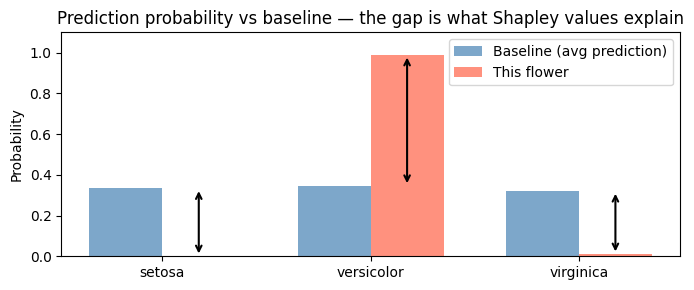

Each column sums to (prediction - baseline) for that class:
proba: [0.   0.99 0.01]
  setosa: sum of φ = -0.3373,  prediction - baseline = -0.3339
  versicolor: sum of φ = +0.6474,  prediction - baseline = +0.6449
  virginica: sum of φ = -0.3101,  prediction - baseline = -0.3110


In [9]:
# Look at the Shapley values for our sample flower, for each class
sample_shap = shap_values.values[0]  # shape: (4 features, 3 classes)

# The table has 4 rows because we have 4 features.
# The table has 3 columns because the model outputs 3 probabilities (one per class).
# Each cell is a separate Shapley value: how much did THIS feature push THIS class's
# probability up or down? A feature can push setosa down and versicolor up at the same time —
# those are different contributions, so they get different values.
# (Binary classifier → 2 columns or 1; regressor → 1 column, no class dimension.)
print('Shapley values for our sample flower:')
df_shap = pd.DataFrame(
    sample_shap,
    index=iris.feature_names,
    columns=[f'φ ({c})' for c in iris.target_names]
)
display(df_shap.round(4))

# Visualize: prediction probability vs baseline for each class
fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(iris.target_names))
width = 0.35
ax.bar(x - width/2, avg_proba, width, label='Baseline (avg prediction)', color='steelblue', alpha=0.7)
ax.bar(x + width/2, proba, width, label='This flower', color='tomato', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(iris.target_names)
ax.set_ylabel('Probability')
ax.set_title('Prediction probability vs baseline — the gap is what Shapley values explain')
ax.legend()
ax.set_ylim(0, 1.1)
for i, (b, p) in enumerate(zip(avg_proba, proba)):
    ax.annotate('', xy=(i + width/2, p), xytext=(i + width/2, b),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
plt.tight_layout()
plt.show()

print('Each column sums to (prediction - baseline) for that class:')
print(f'proba: {proba}')
for i, species in enumerate(iris.target_names):
    total = sample_shap[:, i].sum()
    diff = proba[i] - avg_proba[i]
    print(f'  {species}: sum of φ = {total:+.4f},  prediction - baseline = {diff:+.4f}')


**What you're seeing**: the Shapley values for each feature tell you exactly how much that feature moved the prediction away from the baseline — for this one flower.

And they sum to the total movement. Nothing is lost, nothing is invented. This is called the **efficiency** property.

---

## Step 4 — Visualizing a single prediction: the Waterfall plot

The waterfall plot reads **right to left** — that's the thing that trips everyone up.

- **Bottom right**: `E[f(X)]` — the baseline. What the model would predict on average, before seeing anything specific about this flower.
- **Each bar**: one feature's Shapley value. Blue = pushed the prediction down. Red = pushed it up. The bars stack from right to left.
- **Top left**: `f(x)` — the final prediction. Where you land after all the feature contributions.

So the reading order is: *start at the baseline on the right → follow each bar left or right → arrive at the final prediction on the left.*

Example: if the baseline is 0.337 and all bars are blue (negative), every feature is pushing the prediction *down* from that baseline. The longest blue bars are the features doing the most work.

Think of it like a bank statement: starting balance → each transaction → ending balance. Except it reads right to left.


Waterfall plot for our sample flower — class: setosa


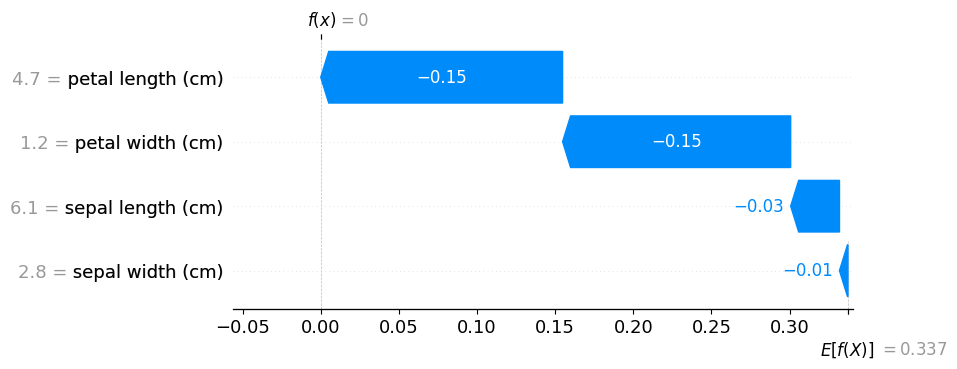

In [10]:
# Build an Explanation object for class 0 (setosa)
class_idx = 0
exp = shap.Explanation(
    values=shap_values.values[:, :, class_idx],
    base_values=shap_values.base_values[:, class_idx],
    data=X_test.values,
    feature_names=iris.feature_names
)

print(f'Waterfall plot for our sample flower — class: {iris.target_names[class_idx]}')
shap.plots.waterfall(exp[0])

---

## Step 5 — Visualizing many predictions at once: the Summary plot

The waterfall shows one flower. The summary plot shows all test flowers at once.

There are four things happening simultaneously — understand each one separately before it clicks.

**1. There are three separate plots — one per class.**
Each panel asks: *for THIS species, what did each feature do?* A feature can look completely different across the three panels.

**2. Y-axis: feature ranking.**
Features are sorted top to bottom by average impact — biggest mover at the top. Just a ranking of what the model cared about most for this class.

**3. X-axis: the Shapley value.**
Same number as in the waterfall. Positive = pushed this class's probability up. Negative = pushed it down. Each dot is one flower, plotted at its Shapley value for that feature.
- Dots spread wide → this feature moved predictions a lot, in different directions for different flowers.
- Dots clustered near zero → this feature barely mattered for anyone.

**4. Color: the actual feature value.**
Red = this flower has a HIGH value for that feature (e.g. long petal). Blue = LOW value (e.g. short petal).
Combine position and color to read the model's logic:
- **Red dot on the right**: high value → pushed prediction UP. Model likes high values for this class.
- **Blue dot on the right**: low value → pushed prediction UP. Model likes low values for this class.
- **Red dot on the left**: high value → pushed prediction DOWN. Model penalizes high values for this class.

**Example — setosa panel, petal length**: blue dots on the right (short petals → pushed setosa probability up) and red dots on the left (long petals → pushed it down). Makes sense — setosas have short petals. The model learned that.

**Example — versicolor panel, reading the features:**
- *Sepal length and width*: dots clustered near zero → model mostly ignored them for this class.
- *Petal width*: blue dots on the left → narrow petals pushed versicolor probability down. Makes sense — versicolors have medium-width petals, narrow ones suggest setosa.
- *Petal length*: dots spread on BOTH sides of zero, with both red and blue on the left. This means both short AND long petals pushed versicolor down. Versicolor lives in the middle of the petal length range — too short = setosa, too long = virginica. Both extremes hurt the versicolor probability. Only medium values push it up. When you see both colors on both sides, the feature has a non-linear relationship with the prediction — not just 'more = better' or 'less = better.'

**Example — virginica panel:**
- *Sepal length and width*: mostly clustered near zero, but sepal length spreads a bit more. That spread means it occasionally matters — red dots lean right (longer sepals push virginica up), blue dots lean left (shorter sepals push it down). It's a weak signal though: useful for some flowers, irrelevant for most.
- *Petal length and width*: blue dots on the left, red dots on the right. Short/narrow petals push virginica probability down; long/wide petals push it up. Clean, strong, consistent signal — the model is confident that virginica means big petals.

Virginica is the 'big flower' species. The summary plot is just showing you the model learned exactly that.


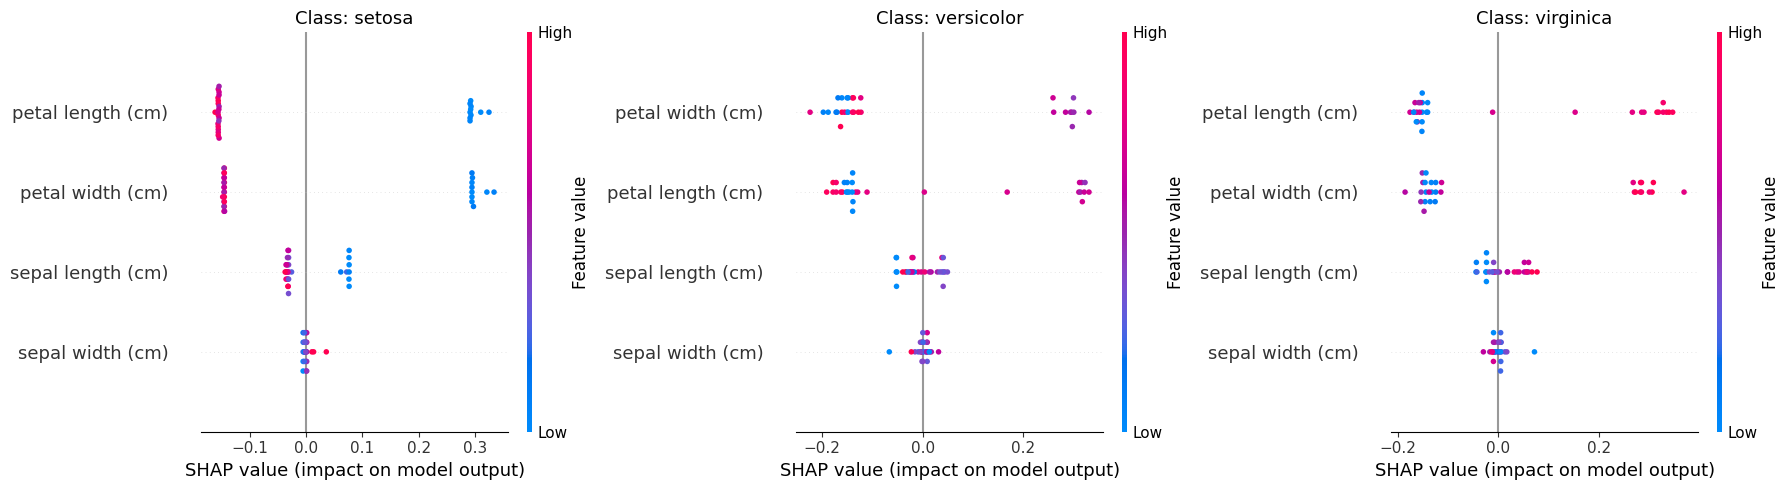

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for class_idx, class_name in enumerate(iris.target_names):
    plt.sca(axes[class_idx])
    shap.summary_plot(
        shap_values.values[:, :, class_idx],
        X_test,
        show=False,
        plot_size=None
    )
    axes[class_idx].set_title(f'Class: {class_name}', fontsize=13)

plt.tight_layout()
plt.show()

---

## Step 6 — Which features matter most overall? The Bar plot

Sometimes you just want a simple ranking: which features had the biggest impact on predictions, on average?

The bar plot shows the **mean absolute Shapley value** per feature — the average size of a feature's impact, ignoring direction.

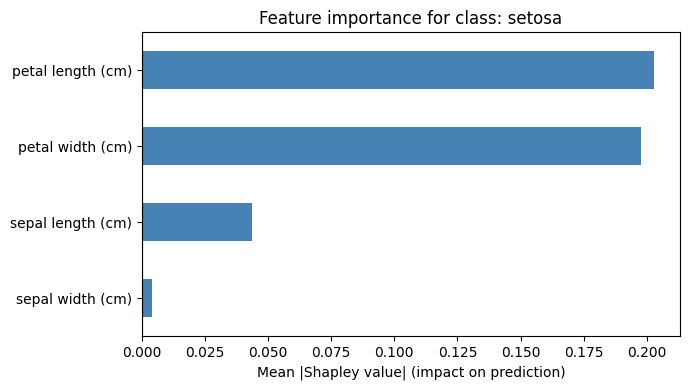

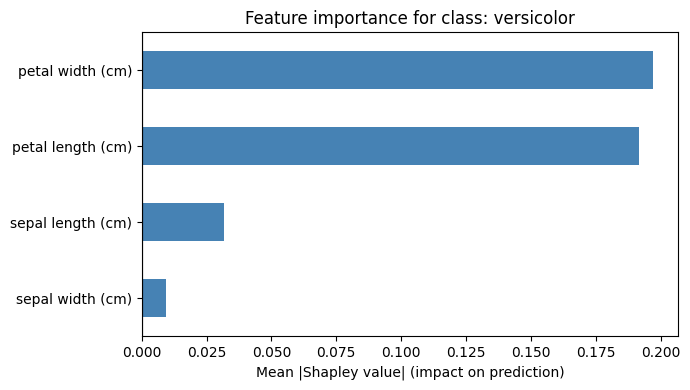

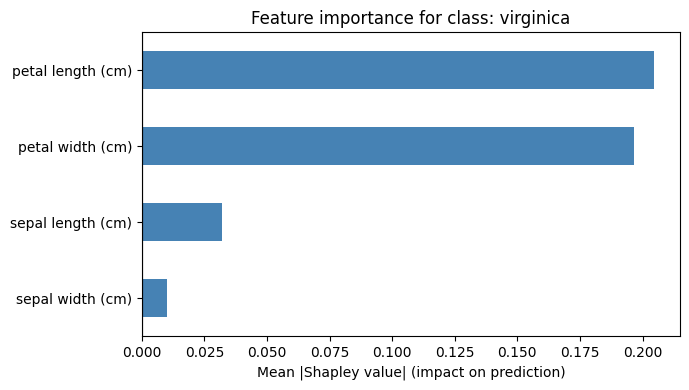

In [12]:
# Mean absolute Shapley value per feature, per class
for class_idx, class_name in enumerate(iris.target_names):
  mean_abs = np.abs(shap_values.values[:, :, class_idx]).mean(axis=0)
  feature_importance = pd.Series(mean_abs, index=iris.feature_names).sort_values(ascending=True)

  fig, ax = plt.subplots(figsize=(7, 4))
  feature_importance.plot.barh(ax=ax, color='steelblue')
  ax.set_xlabel('Mean |Shapley value| (impact on prediction)')
  ax.set_title(f'Feature importance for class: {class_name}')
  ax.axvline(0, color='black', lw=0.8)
  plt.tight_layout()
  plt.show()

---

## Step 7 — Build the intuition manually

Let's implement a tiny version of the Shapley algorithm by hand. This is the best way to really understand what's happening.

**The problem we're solving**: we want to know how much one specific feature — say, petal length — contributed to a prediction. But we can't just "remove" it, because the model needs all 4 features to run.

**The workaround**: instead of removing petal length, we *replace* it with petal length from a different, randomly chosen flower from the training set. That other flower is the "background flower" — it's just a stand-in. A placeholder. Its job is to fill the slot so the model can still run, but with *our* flower's petal length swapped out.

We do this twice — once with our flower's petal length in the slot, once with the background flower's petal length — and compare the predictions. The difference is petal length's contribution for this one trial.

**The full recipe:**

1. Pick the feature `j` you want to explain (e.g. petal length).
2. Pick a random ordering of all features (e.g. [sepal width, petal length, sepal length, petal width]).
3. Grab a random flower from the training set as your background stand-in.
4. Build two hybrid flowers — **identical except for feature `j`**. That's the only way to isolate `j`'s contribution:
   - **With `j`**: features that appear *before and including* `j` in the ordering come from your flower. Everything after comes from the background stand-in.
   - **Without `j`**: features that appear *before* `j` come from your flower. `j` and everything after come from the background stand-in.

   Example — ordering: [sepal width, **petal length**, sepal length, petal width], j = petal length:

   | Feature | With j | Without j |
   |---|---|---|
   | sepal width | your flower | your flower |
   | **petal length** | **your flower** | **background** |
   | sepal length | background | background |
   | petal width | background | background |

   Everything is identical except petal length — so the difference in predictions can only be caused by petal length.

   The ordering determines which features are already "in" when `j` arrives. Features before `j` are already contributing — they come from your flower in both hybrids. Features after `j` haven't arrived yet — they come from the background in both hybrids. `j` is the only thing that changes.

5. Run the model on both hybrids. The difference in predictions = `j`'s contribution in this ordering.
6. Repeat steps 2–5 many times with different orderings and different background flowers. Average the contributions.

That's why you try many orderings — `j`'s contribution might be different depending on which features are already "in" when it arrives. Averaging across all orderings gives you the fair, order-independent Shapley value.

That average is the Shapley value. The background flower isn't special — any real flower from the training set works. We use many different ones to average out any quirks from a single choice.


In [13]:
def estimate_shapley_values(model, instance, background, feature_names, n_samples=500, class_idx=0, random_state=42):
    """
    Monte Carlo estimate of Shapley values for one instance.

    For each random ordering and each feature j:
      - 'with_j' hybrid: features before j AND j come from instance, rest from background
      - 'without_j' hybrid: features before j come from instance, j AND rest from background
    Marginal contribution = predict(with_j) - predict(without_j)
    Average over many orderings.
    """
    rng = np.random.default_rng(random_state)
    n_features = len(instance)
    phi = np.zeros(n_features)

    for _ in range(n_samples):
        # Random background row and random feature ordering
        bg = background[rng.integers(len(background))].copy()
        ordering = rng.permutation(n_features)

        for pos, j in enumerate(ordering):
            # Features at positions 0..pos (inclusive) → from instance
            with_j = bg.copy()
            for k in ordering[:pos + 1]:
                with_j[k] = instance[k]

            # Features at positions 0..pos-1 → from instance (j stays as background)
            without_j = bg.copy()
            for k in ordering[:pos]:
                without_j[k] = instance[k]

            # Wrap in DataFrame so sklearn doesn't warn about missing feature names
            pred_with = model.predict_proba(pd.DataFrame([with_j], columns=feature_names))[0, class_idx]
            pred_without = model.predict_proba(pd.DataFrame([without_j], columns=feature_names))[0, class_idx]

            phi[j] += pred_with - pred_without

    return phi / n_samples


instance = X_test.values[0]
background = X_train.values

phi_manual = estimate_shapley_values(clf, instance, background, feature_names=iris.feature_names, n_samples=500, class_idx=0)
phi_shap = shap_values.values[0, :, 0]  # From the TreeExplainer

print('Comparison — manual Monte Carlo vs TreeExplainer (class: setosa):')
print(f'{"Feature":<25} {"Manual":>10} {"TreeExplainer":>14}')
print('-' * 52)
for name, manual, exact in zip(iris.feature_names, phi_manual, phi_shap):
    print(f'{name:<25} {manual:>10.4f} {exact:>14.4f}')


Comparison — manual Monte Carlo vs TreeExplainer (class: setosa):
Feature                       Manual  TreeExplainer
----------------------------------------------------
sepal length (cm)            -0.0106        -0.0312
sepal width (cm)             -0.0052        -0.0054
petal length (cm)            -0.1534        -0.1547
petal width (cm)             -0.1555        -0.1459


The manual estimates are close to the exact values from TreeExplainer — the difference is just noise from Monte Carlo sampling. More samples → closer.

This confirms you now understand what TreeExplainer is actually computing under the hood.

---

## Step 8 — Three things that will trip you up

### Trap 1: A Shapley value is NOT "what happens if I remove this feature"

This is the most common misreading.

If petal length has a Shapley value of `+0.20`, it does NOT mean: "if I deleted petal length from the input, the prediction would drop by 0.20."

It means: "across all possible combinations of features, petal length's presence contributed +0.20 on average."

The difference matters because removing a feature entirely is a different operation from the Frankenstein hybrid approach Shapley uses.

---

### Trap 2: Shapley values are not causal

If income has a high Shapley value, it doesn't mean income *caused* the outcome. It means the model used income heavily for this prediction. The model could be wrong. Income could be a proxy for something else.

Shapley explains the model. It doesn't explain the world.

---

### Trap 3: Correlated features distort the picture

The Frankenstein hybrid approach assumes you can freely mix features from different flowers. But in real data, features are often correlated — tall people tend to weigh more; people with high income tend to have less debt.

When you mix features naively, you create impossible combinations (short + heavy, high income + huge debt). The model has never seen these and its predictions on them can be misleading.

TreeExplainer has an option `feature_perturbation='tree_path_dependent'` that handles this better for tree models.

In [14]:
# Demonstrate Trap 3: same model, different Shapley values depending on reference data
explainer_full = shap.TreeExplainer(clf, X_train)  # background = full training set
explainer_small = shap.TreeExplainer(clf, X_train.iloc[:10])  # background = 10 samples

sv_full = explainer_full(X_test.iloc[[0]])
sv_small = explainer_small(X_test.iloc[[0]])

print('Same model, same prediction, different background data → different Shapley values')
print(f'(class: setosa, feature: petal length)')
print(f'  Full background:  {sv_full.values[0, 2, 0]:+.4f}')
print(f'  10-sample background: {sv_small.values[0, 2, 0]:+.4f}')
print()
print('This is why your choice of reference data matters.')

Same model, same prediction, different background data → different Shapley values
(class: setosa, feature: petal length)
  Full background:  -0.1665
  10-sample background: -0.3320

This is why your choice of reference data matters.


---

## Summary

| Question | Answer |
|---|---|
| What is a Shapley value? | How much one feature contributed to pushing *this* prediction above or below the average |
| How is it computed? | Average the feature's marginal contribution across all possible orderings of features |
| Why average across orderings? | So the result doesn't depend on an arbitrary order — it's the fairest split possible |
| Do Shapley values sum to anything? | Yes — they sum to `prediction − average_prediction` (efficiency property) |
| Why not compute exactly? | 2^n subsets needed — exponential. Use TreeExplainer for trees (fast + exact) |
| What does a positive Shapley value mean? | This feature pushed *this prediction* above the baseline |
| Does that mean increasing the feature increases the prediction? | **No.** Shapley is about the current value, not about changing it |
| Is it causal? | **No.** It explains the model, not the real world |

---

## What to read next

- [Interpretable ML Book — Shapley Values](https://christophm.github.io/interpretable-ml-book/shapley.html) — the source for this notebook
- [SHAP library docs](https://shap.readthedocs.io/) — API reference and more plot types
- [Original SHAP paper (Lundberg & Lee, 2017)](https://proceedings.neurips.cc/paper_files/paper/2017/file/8a20a8621978632d76c43dfd28b67767-Paper.pdf)